# Artificial Intelligence Technology and Application

## Machine Learning Lab Guide - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 Real-Time Recommendation Practice for Retail Products

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 User-Item Matrix
Ratings are stored as a table where rows are users and columns are products.


In [1]:
import numpy as np
import pandas as pd

ratings = pd.DataFrame(
    [[5, 4, 0, 1, 0], [4, 5, 0, 1, 1], [0, 1, 5, 4, 4], [1, 0, 4, 5, 5], [5, 4, 1, 0, 0]],
    index=["U1", "U2", "U3", "U4", "U5"],
    columns=["phone", "charger", "book", "headset", "camera"],
)
print(ratings)


    phone  charger  book  headset  camera
U1      5        4     0        1       0
U2      4        5     0        1       1
U3      0        1     5        4       4
U4      1        0     4        5       5
U5      5        4     1        0       0


## 1.2 Similarity Recommendation
Cosine similarity finds neighbors with similar purchase taste.


In [2]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = pd.DataFrame(cosine_similarity(ratings), index=ratings.index, columns=ratings.index)
target = "U1"
neighbors = similarity[target].drop(target).sort_values(ascending=False)
weighted = ratings.loc[neighbors.index].mul(neighbors, axis=0).sum() / neighbors.sum()
unseen = ratings.loc[target] == 0
print("neighbors:")
print(neighbors.round(3))
print("recommendations:")
print(weighted[unseen].sort_values(ascending=False).round(2))


neighbors:
U5    0.976
U2    0.965
U4    0.189
U3    0.162
Name: U1, dtype: float64
recommendations:
camera    1.12
book      1.11
dtype: float64


## 1.3 Matrix Factorization
Truncated SVD compresses product preferences into latent factors.


In [3]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=3)
latent = svd.fit_transform(ratings)
print("explained variance:", svd.explained_variance_ratio_.round(3))
print(pd.DataFrame(latent, index=ratings.index, columns=["factor_a", "factor_b"]).round(2))


explained variance: [0.014 0.933]
    factor_a  factor_b
U1      4.91      4.17
U2      5.28      3.70
U3      5.81     -4.79
U4      6.29     -5.14
U5      4.87      4.13


## 1.4 Heatmap
The matrix plot makes sparse preferences easy to inspect.


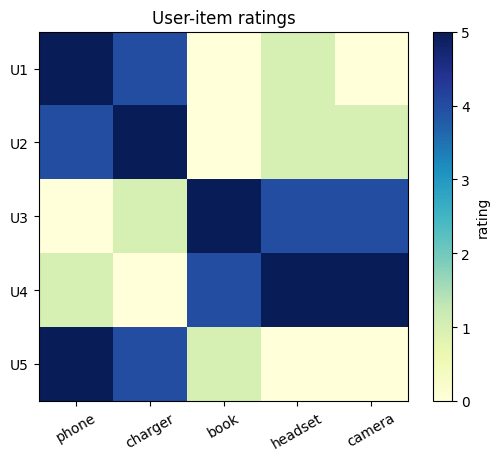

In [4]:
import matplotlib.pyplot as plt

plt.imshow(ratings, cmap="YlGnBu")
plt.xticks(range(len(ratings.columns)), ratings.columns, rotation=30)
plt.yticks(range(len(ratings.index)), ratings.index)
plt.colorbar(label="rating")
plt.title("User-item ratings")
plt.show()
